import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from prophet import Prophet



load dataset

In [ ]:
sales = pd.read_csv("restaurant_sales.csv", parse_dates=["date"])
weather = pd.read_csv("Daily_Weather_Insights.csv", parse_dates=["Date"])
holidays = pd.read_csv("Global_Holidays_2025_2035.csv", parse_dates=["Date"])

/tmp/ipykernel_13444/2494791094.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  holidays = pd.read_csv("Global_Holidays_2025_2035.csv", parse_dates=["Date"])


In [ ]:
weather.rename(columns={"Date":"date"}, inplace=True)
holidays.rename(columns={"Date":"date"}, inplace=True)

In [ ]:
print(sales.head(5))

        date   sales
0 2025-01-01  281.64
1 2025-01-02  212.74
2 2025-01-03  250.61
3 2025-01-04  253.38
4 2025-01-05  253.00


In [ ]:
sales.index=sales['date']

In [ ]:
print(sales.head(5))

                 date   sales
date                         
2025-01-01 2025-01-01  281.64
2025-01-02 2025-01-02  212.74
2025-01-03 2025-01-03  250.61
2025-01-04 2025-01-04  253.38
2025-01-05 2025-01-05  253.00


In [ ]:
del sales['date']

In [ ]:
print(sales.head(5))

             sales
date              
2025-01-01  281.64
2025-01-02  212.74
2025-01-03  250.61
2025-01-04  253.38
2025-01-05  253.00


In [ ]:
sales.isnull().sum().sum()

0

In [ ]:
sales.duplicated().sum()

6

In [ ]:
sales.drop_duplicates(inplace=True)

In [ ]:
sales.duplicated().sum()

0

In [ ]:
print(weather.head(5))

        date   City  Temperature_High (°C)  Temperature_Low (°C)  \
0 2025-01-01  Cairo                   16.9                  14.1   
1 2025-01-02  Cairo                   15.1                   5.6   
2 2025-01-03  Cairo                   25.1                  18.2   
3 2025-01-04  Cairo                   28.9                   9.9   
4 2025-01-05  Cairo                   17.6                  13.7   

   Humidity (%)  Wind_Speed (km/h) Weather_Condition  Air_Quality_Index  \
0          43.1               24.2             Sunny                145   
1          56.9                8.2             Windy                115   
2          52.5               18.2             Snowy                 11   
3          76.3               18.8             Rainy                 22   
4          55.6               10.8             Sunny                 39   

   Precipitation (mm)  Visibility (km)  
0                17.2              4.7  
1                 0.5              9.8  
2                

In [ ]:
weather.index=weather['date']

In [ ]:
del weather['date']

In [ ]:
print(weather.head(5))

             City  Temperature_High (°C)  Temperature_Low (°C)  Humidity (%)  \
date                                                                           
2025-01-01  Cairo                   16.9                  14.1          43.1   
2025-01-02  Cairo                   15.1                   5.6          56.9   
2025-01-03  Cairo                   25.1                  18.2          52.5   
2025-01-04  Cairo                   28.9                   9.9          76.3   
2025-01-05  Cairo                   17.6                  13.7          55.6   

            Wind_Speed (km/h) Weather_Condition  Air_Quality_Index  \
date                                                                 
2025-01-01               24.2             Sunny                145   
2025-01-02                8.2             Windy                115   
2025-01-03               18.2             Snowy                 11   
2025-01-04               18.8             Rainy                 22   
2025-01-05         

In [ ]:
weather.isnull().sum().sum()

0

In [ ]:
weather.duplicated().sum()

0

In [ ]:
print(weather.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90 entries, 2025-01-01 to 2025-03-31
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   City                   90 non-null     object 
 1   Temperature_High (°C)  90 non-null     float64
 2   Temperature_Low (°C)   90 non-null     float64
 3   Humidity (%)           90 non-null     float64
 4   Wind_Speed (km/h)      90 non-null     float64
 5   Weather_Condition      90 non-null     object 
 6   Air_Quality_Index      90 non-null     int64  
 7   Precipitation (mm)     90 non-null     float64
 8   Visibility (km)        90 non-null     float64
dtypes: float64(6), int64(1), object(2)
memory usage: 7.0+ KB
None


In [ ]:
print(holidays.head(5))

  Country  Year                 date               Holiday_Name  Local_Name  \
0      IN  2025  2025-01-01 00:00:00             New Year's Day         NaN   
1      IN  2025  2025-02-01 00:00:00       Last day of Hanukkah         NaN   
2      IN  2025  2025-06-01 00:00:00  Guru Govind Singh Jayanti         NaN   
3      IN  2025  2025-01-13 00:00:00                      Lohri         NaN   
4      IN  2025  2025-01-14 00:00:00                     Pongal         NaN   

                         Type  
0            Optional holiday  
1                  Observance  
2            Optional holiday  
3                  Observance  
4  Hinduism, Optional holiday  


In [ ]:
holidays['date'] = pd.to_datetime(holidays['date'], format='%Y-%m-%d', errors='coerce')

In [ ]:
holidays = holidays[holidays['date'].between('2025-01-01','2028-12-31')]

In [ ]:
holidays.index=holidays['date']

In [ ]:
del holidays['date']
del holidays['Local_Name']


In [ ]:
del holidays['Year']

In [ ]:
holidays.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19 entries, 2025-01-01 to 2025-03-14
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country       19 non-null     object
 1   Holiday_Name  19 non-null     object
 2   Type          19 non-null     object
dtypes: object(3)
memory usage: 608.0+ bytes


In [ ]:
holidays.isnull().sum().sum()

0

In [ ]:
holidays.duplicated().sum()

0

In [ ]:
holidays.shape

(19, 3)

In [ ]:
# Merge sales with weather and holidays
df = sales.merge(weather, on="date", how="left")
df = df.merge(holidays, on="date", how="left")



In [ ]:
df.head(5)

,sales,City,Temperature_High (°C),Temperature_Low (°C),Humidity (%),Wind_Speed (km/h),Weather_Condition,Air_Quality_Index,Precipitation (mm),Visibility (km),Country,Holiday_Name,Type
date,,,,,,,,,,,,,
2025-01-01,281.64,Cairo,16.9,14.1,43.1,24.2,Sunny,145.0,17.2,4.7,IN,New Year's Day,Optional holiday
2025-01-02,212.74,Cairo,15.1,5.6,56.9,8.2,Windy,115.0,0.5,9.8,NaN,NaN,NaN
2025-01-03,250.61,Cairo,25.1,18.2,52.5,18.2,Snowy,11.0,6.0,2.5,NaN,NaN,NaN
2025-01-04,253.38,Cairo,28.9,9.9,76.3,18.8,Rainy,22.0,6.8,9.4,NaN,NaN,NaN
2025-01-05,253.00,Cairo,17.6,13.7,55.6,10.8,Sunny,39.0,12.6,4.5,NaN,NaN,NaN


In [ ]:
df['Country'].unique()

array(['IN', nan], dtype=object)

In [ ]:
df['Country'] = df['Country'].fillna('No Country')
df['Holiday_Name'] = df['Holiday_Name'].fillna('No Holiday')
df['Type'] = df['Type'].fillna('No Type')

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(0)
print(df.isnull().sum().sum())

0


In [ ]:
from statsmodels.tsa.stattools import adfuller

if not df['sales_stationay'].empty:
  result=adfuller(df['sales_stationay'])
  p_value=result[1]
  if p_value < 0.05:
    print("accepted as stationary")
  else:
    print("rejected as non stationary")
else:
  print("Cannot perform ADFuller test: 'sales_stationay' series is empty after data processing.")

accepted as stationary


In [ ]:
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)
df["is_holiday"] = df["Holiday_Name"].notnull().astype(int)
df['day']=df.index.day

In [ ]:
#lag feature
df['sales_lag_1'] = df['sales'].shift(1)
df['sales_lag_2'] = df['sales'].shift(7)

In [ ]:
df['sales_lag_1'] = df['sales_lag_1'].fillna(0)
df['sales_lag_2'] = df['sales_lag_2'].fillna(0)

In [ ]:
#rolling avg feature
df['rolling_mean_7'] = df['sales'].rolling(window=7).mean()
df['rolling_mean_14'] = df['sales'].rolling(window=14).mean()

In [ ]:
# Optional: cap extreme outliers (holiday spikes)
q_low, q_high = sales['sales'].quantile([0.01, 0.99])
sales['sales'] = np.clip(sales['sales'], q_low, q_high)

In [ ]:
#sales numbers to stay strictly within outlier(adding treshold)
df['sales_capped']=df['sales'].clip(lower=q_low,upper=q_high)

In [ ]:
df['log_sales'] = np.log(df['sales'])

In [ ]:
#if u used log
df['sales_diff1'] = df['log_sales'].diff(periods=1)
#if u did not use log
df['sales_diff1'] = df['sales'].diff(periods=1)

In [ ]:
#apply a 7 days difference to the difference data
df['sales_stationay']=df['sales_diff1'].diff(periods=7)

In [ ]:
df['rolling_mean_7'] = df['rolling_mean_7'].fillna(0)
df['rolling_mean_14'] = df['rolling_mean_14'].fillna(0)
df['sales_diff1'] = df['sales_diff1'].fillna(0)
df['sales_stationay'] = df['sales_stationay'].fillna(0)

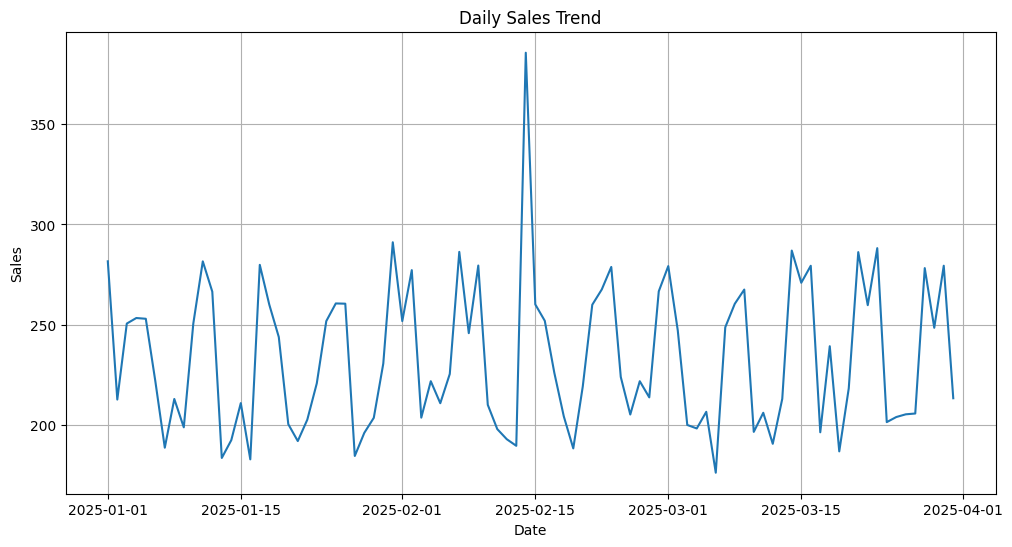

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['sales'])
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

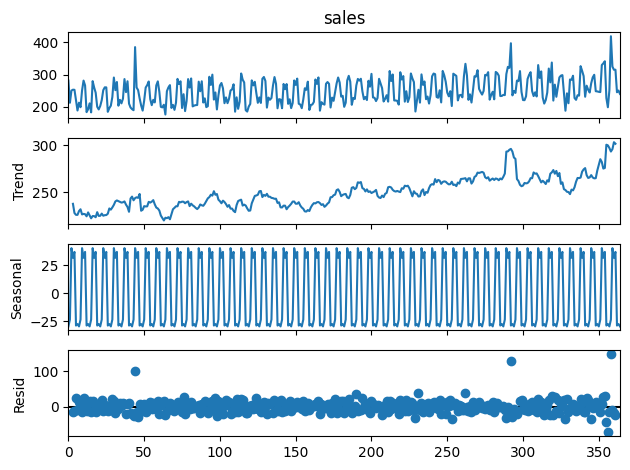

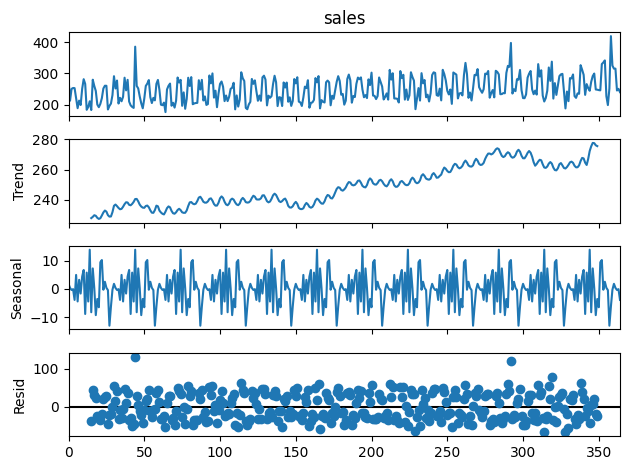

In [ ]:
# eda: decompose seasonality (weekly pattern)
result = seasonal_decompose(sales['sales'], model='additive', period=7)
result.plot()
plt.show()

# Monthly decomposition (if dataset spans >1 year)
result_month = seasonal_decompose(sales['sales'], model='additive', period=30)
result_month.plot()
plt.show()


<Figure size 1200x400 with 0 Axes>

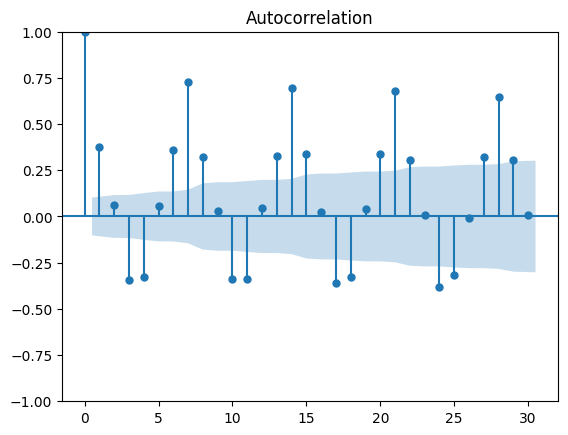

<Figure size 1200x400 with 0 Axes>

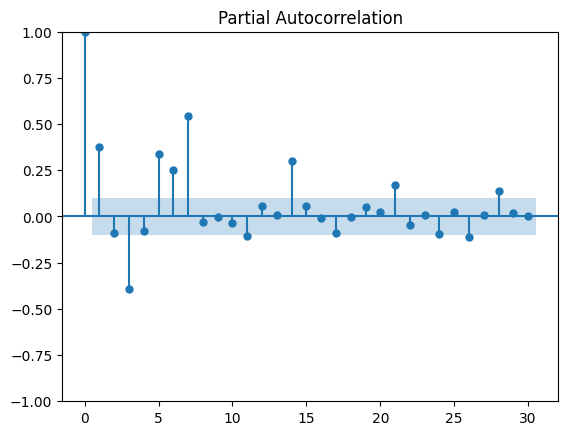

In [ ]:
# eda: autocorrelation & partial autocorrelation
plt.figure(figsize=(12,4))
plot_acf(sales['sales'].dropna(), lags=30)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(sales['sales'].dropna(), lags=30)
plt.show()


ACF (Autocorrelation Function): Shows correlation of the series with its own lagged values. Useful for detecting MA (moving average) terms.

PACF (Partial Autocorrelation Function): Shows correlation after removing effects of shorter lags. Useful for detecting AR (autoregressive) terms.

Peaks outside the confidence interval (blue shaded area) indicate significant correlation at that lag.

In [ ]:
x=df.drop('sales',axis=1)
y=df['sales']

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
model=ARIMA(train,order=(1,0,1))
model_fit=model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


<Axes: xlabel='date'>

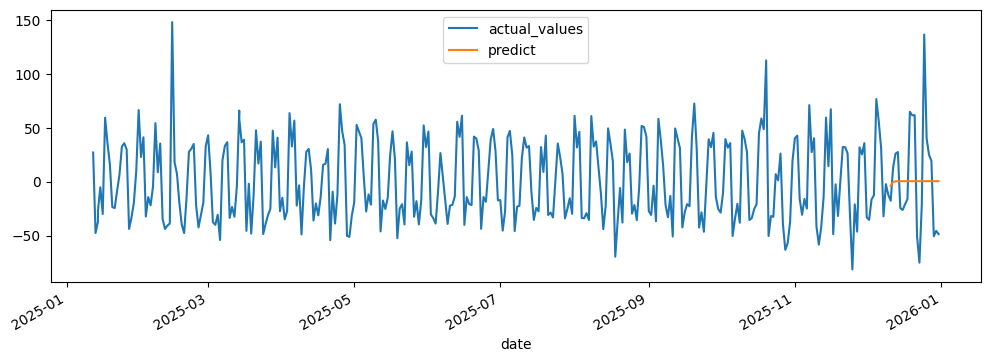

In [ ]:
predictions = model_fit.predict(start=len(train), end=len(train)+len(test)-1, typ='levels')

# Explicitly align predictions with the test set's index
predictions.index = test.index

# Reconstruct the full actual series by concatenating train and test
# Assuming 'train' and 'test' are the relevant time series for actual values (e.g., differenced sales)
actual_series_for_plot = pd.concat([train, test])

# Create a full-length series for predictions, filled with NaNs for the training period
full_predictions = pd.Series(index=actual_series_for_plot.index, dtype=float)
full_predictions.loc[predictions.index] = predictions # Assign predictions to the test period

# Create the DataFrame for plotting
plot_df = pd.DataFrame({'actual_values': actual_series_for_plot, 'predict': full_predictions})
plot_df[['actual_values','predict']].plot(figsize=(12,4))

In [ ]:
!pip install numpy==1.26.4

In [ ]:
!pip install pmdarima

In [ ]:
from pmdarima import auto_arima

In [ ]:
# Log transformation of sales
df['log_sales'] = np.log(df['sales'].replace(0, np.nan).fillna(method='ffill')) # Handle potential zeros before log

/tmp/ipykernel_13444/3047013811.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['log_sales'] = np.log(df['sales'].replace(0, np.nan).fillna(method='ffill')) # Handle potential zeros before log


In [ ]:
# First differencing
df['sales_diff1'] = df['log_sales'].diff(periods=1)
df['sales_diff1'] = df['sales_diff1'].fillna(0)

In [ ]:
# Seasonal differencing for stationarity
df['sales_stationay']=df['sales_diff1'].diff(periods=7)
df['sales_stationay'] = df['sales_stationay'].fillna(0)

In [ ]:
# Final check for NaNs before ADFuller test
print("Total NaN values before ADFuller test:", df.isnull().sum().sum())

Total NaN values before ADFuller test: 550


In [ ]:
from statsmodels.tsa.stattools import adfuller

if not df['sales_stationay'].empty:
  result=adfuller(df['sales_stationay'])
  p_value=result[1]
  if p_value < 0.05:
    print("accepted as stationary")
  else:
    print("rejected as non stationary")
else:
  print("Cannot perform ADFuller test: 'sales_stationay' series is empty after data processing.")

accepted as stationary


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical features
store_encoder = LabelEncoder()
df["store_id_enc"] = store_encoder.fit_transform(df["store_id"])

# Scale continuous features
scaler = StandardScaler()
df[["sales","temperature","rainfall"]] = scaler.fit_transform(df[["sales","temperature","rainfall"]])
